# Curvas dinamicas

Ejecuta los modelos disponibles usando los materiales de `examples/data/section_01_materials.json`. Para uso directo de curvas, si el material no trae `sigma_vertical`, el ejemplo fija explicitamente 100 kPa.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "dynaengine").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = ROOT / "examples" / "data"
MATERIALS_PATH = DATA_DIR / "section_01_materials.json"
materials = json.loads(MATERIALS_PATH.read_text(encoding="utf-8"))
print(f"Proyecto: {ROOT}")
print(f"Materiales cargados: {len(materials)}")

import pandas as pd
import matplotlib.pyplot as plt
from dynaengine import DEFAULT_SIGMA_VERTICAL_KPA, DynamicModelSpec, evaluate_dynamic_curve
from dynaengine.plots import plot_dynamic_curve

Proyecto: C:\Users\joel.alarcon\Desktop\_code\prismo\external\DynaEngine
Materiales cargados: 6


In [2]:
def curve_spec_for_direct_use(material, sigma_vertical_kpa=DEFAULT_SIGMA_VERTICAL_KPA):
    spec = dict(material["dynamic_model"])
    model_spec = DynamicModelSpec.from_mapping(spec)
    if model_spec.sigma_vertical_assumed:
        spec["sigma_vertical"] = sigma_vertical_kpa
        sigma_source = "default explicito para curva directa"
        sigma_used = sigma_vertical_kpa
    else:
        sigma_source = "definido en material"
        sigma_used = model_spec.sigma_vertical_kpa
    return spec, sigma_used, sigma_source

summary = []
curves = {}
for material in materials:
    spec, sigma_used, sigma_source = curve_spec_for_direct_use(material)
    curve = evaluate_dynamic_curve(spec)
    curves[material["material_name"]] = curve
    summary.append({
        "material_name": material["material_name"],
        "model_type": curve.model_type,
        "sigma_vertical_kpa": sigma_used,
        "sigma_source": sigma_source,
        "strain_min": curve.strain.min(),
        "strain_max": curve.strain.max(),
        "ggmax_min": curve.ggmax.min(),
        "damping_max_percent": curve.damping_percent.max(),
    })

display(pd.DataFrame(summary))

,material_name,model_type,sigma_vertical_kpa,sigma_source,strain_min,strain_max,ggmax_min,damping_max_percent
0,Material de poza,darendeli_2001,100.0,default explicito para curva directa,0.000001,0.1,0.005231,21.055289
1,Material del dique,menq_2003,100.0,default explicito para curva directa,0.000001,0.1,0.004983,18.279880
2,Grava arcillosa,wang_2021,100.0,default explicito para curva directa,0.000001,0.1,0.033853,12.120250
3,Grava arenosa,rollins_2020,100.0,default explicito para curva directa,0.000001,0.1,0.011621,18.208974
4,Grava pobremente gradada,ishibashi_1993,100.0,default explicito para curva directa,0.000001,0.1,0.022445,17.618654
5,Estrato no identificado 1,rojas_2019,100.0,default explicito para curva directa,0.000001,0.1,0.010000,24.400000


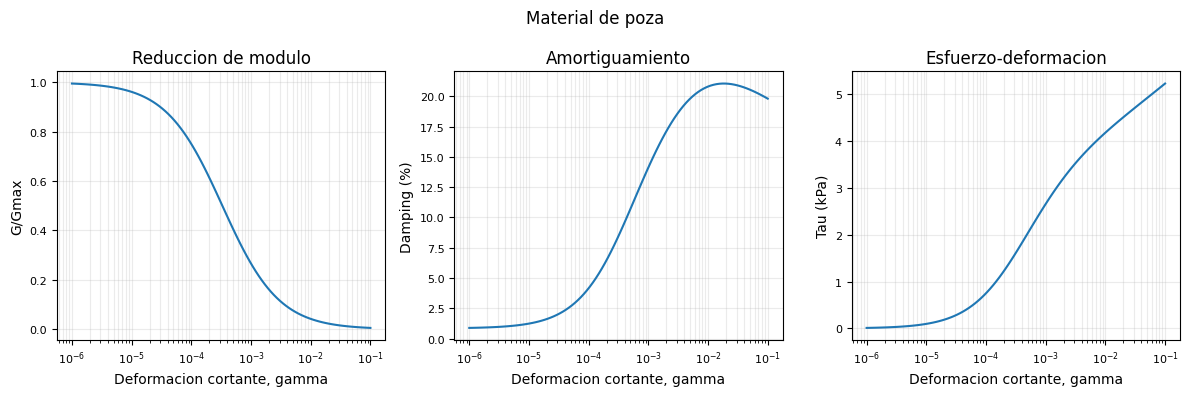

In [3]:
material_name = materials[0]["material_name"]
fig, axes = plot_dynamic_curve(curves[material_name])
fig.suptitle(material_name)
fig.tight_layout()
display(fig)
plt.close(fig)

In [6]:
calibrated_darendeli_spec = {
    "model_type": "calibrated_darendeli",
    "sigma_vertical": 100,
    "soil_parameters": {
        "k0": 0.7,
        "a1": 0.92,
        "a2": 0.0,
        "y1": 4e-4,
        "y2": 0.0,
        "D1": 3.0,
        "D2": -2.0,
        "D3": 1.0,
        "Dmin": 0.7,
    },
    "gmax_mpa": 70,
}
calibrated_darendeli = evaluate_dynamic_curve(calibrated_darendeli_spec)
display(calibrated_darendeli.as_frame())

,strain,ggmax,damping_percent,shear_stress_kpa
0,0.000001,0.995979,2.683964,0.069719
1,0.000001,0.995527,2.682167,0.078281
2,0.000001,0.995024,2.680171,0.087890
3,0.000001,0.994465,2.677953,0.098674
4,0.000002,0.993844,2.675491,0.110774
...,...,...,...,...
95,0.062803,0.009454,1.681360,41.562929
96,0.070548,0.008503,1.683211,41.991690
97,0.079248,0.007647,1.684881,42.420777
98,0.089022,0.006876,1.686389,42.850522
